In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [24]:
data = pd.read_csv('Published Data/combined_COPUS_CI_data.csv')
labels = [ 'Lec', 'CG', 'CQ', 'WG', 'SQ']
WGs, CGs, CQs, SQs, Lecs = data['WG'].values, data['CG'].values, data['CQ'].values, data['SQ'].values, data['Lec'].values
COPUS_data = data[labels].values
effect_sizes = data['Effect Size'].values
n_features = COPUS_data.shape[1]
post_stds = data['PostStd'].values
pre_stds = data['PreStd'].values
std_diffs = post_stds - pre_stds
#########################
std_props = post_stds / pre_stds
##########################
premeans = data['PreMean'].values
postmeans = data['PostMean'].values
gains = postmeans - premeans

Ns = data['N'].values
Fields = data['Field'].values

## Covariance

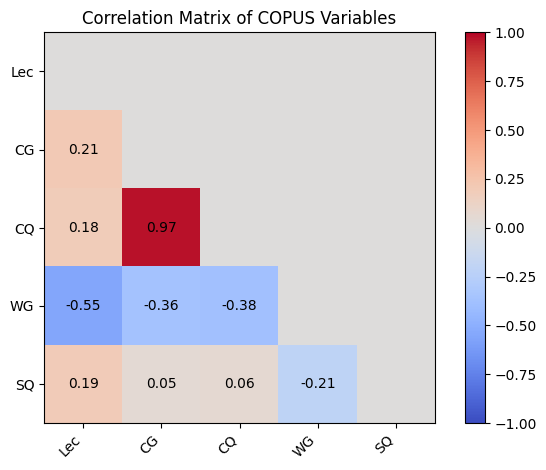

In [25]:
n_features = COPUS_data.shape[1]
corr = np.corrcoef(COPUS_data.T)


corr[corr == 1] = 0
#label each pixel with the numeric value
for i in range(n_features):
    for j in range(n_features):
        if j < i:
            plt.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', color='black')
        else: corr[i,j] = 0
plt.imshow(corr, vmin = -1, vmax=1, cmap='coolwarm')
plt.colorbar()
plt.xticks(np.arange(n_features), labels, rotation=45, ha='right')
plt.yticks(np.arange(n_features), labels)
plt.title('Correlation Matrix of COPUS Variables')
plt.tight_layout()
plt.show()


## Effect Size and Post Test Variance Trends

Text(0, 0.5, 'Effect Size')

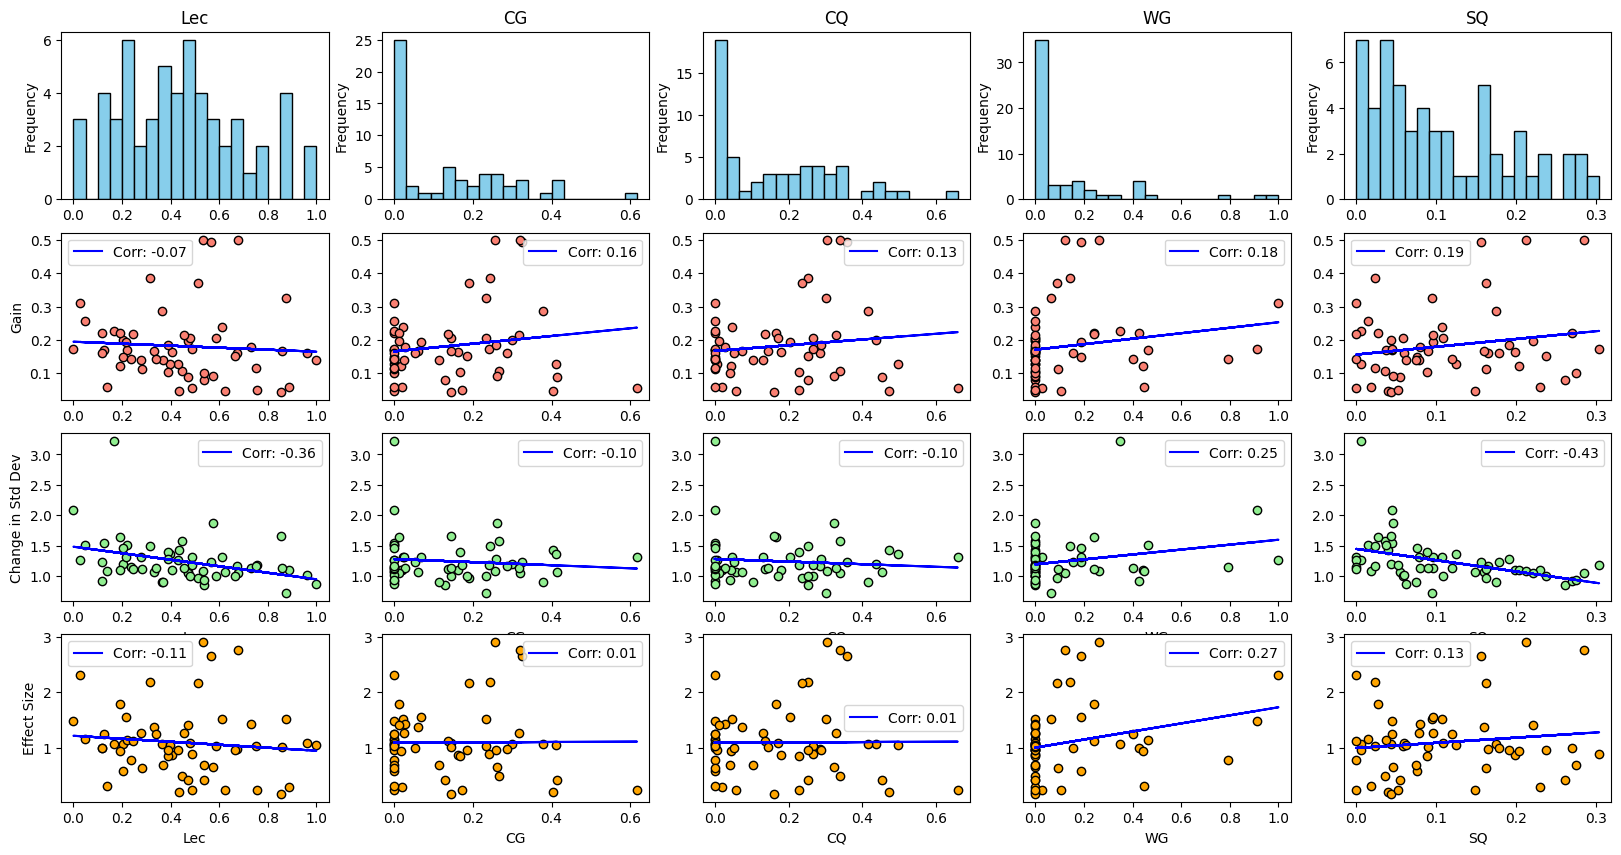

In [26]:
fig, ax = plt.subplots(4, n_features, figsize=(20, 10))
for i in range(n_features):

    ax[0, i].set_title(labels[i])
    ax[0, i].hist(COPUS_data[:, i], bins=20, color='skyblue', edgecolor='black')
    ax[0, i].set_ylabel('Frequency')
    
    ax[1, i].scatter(COPUS_data[:, i], gains, color='salmon', edgecolor='black')
    #fit line
    m, b = np.polyfit(COPUS_data[:, i], gains, 1)
    corr = np.corrcoef(COPUS_data[:, i], gains)[0, 1]
    ax[1, i].plot(COPUS_data[:, i], m*COPUS_data[:, i] + b, color='blue', label = f'Corr: {corr:.2f}')
    ax[1, i].legend()

    ax[2, i].scatter(COPUS_data[:, i], std_props, color='lightgreen', edgecolor='black')
    ax[2, i].set_xlabel(labels[i])
    #fit line
    m, b = np.polyfit(COPUS_data[:, i], std_props, 1)
    corr = np.corrcoef(COPUS_data[:, i], std_props)[0, 1]
    ax[2, i].plot(COPUS_data[:, i], m*COPUS_data[:, i] + b, color='blue', label = f'Corr: {corr:.2f}')
    ax[2, i].legend()


    ax[3, i].scatter(COPUS_data[:, i], effect_sizes, color='orange', edgecolor='black')
    ax[3, i].set_xlabel(labels[i])
    #fit line
    m, b = np.polyfit(COPUS_data[:, i], effect_sizes, 1)
    corr = np.corrcoef(COPUS_data[:, i], effect_sizes)[0, 1]
    ax[3, i].plot(COPUS_data[:, i], m*COPUS_data[:, i] + b, color='blue', label = f'Corr: {corr:.2f}')
    ax[3, i].legend()

ax[1, 0].set_ylabel('Gain')
ax[2, 0].set_ylabel('Change in Std Dev')
ax[3, 0].set_ylabel('Effect Size')

## Effect Size vs. Gain

Text(0.5, 1.0, 'Effect Size vs. Gain')

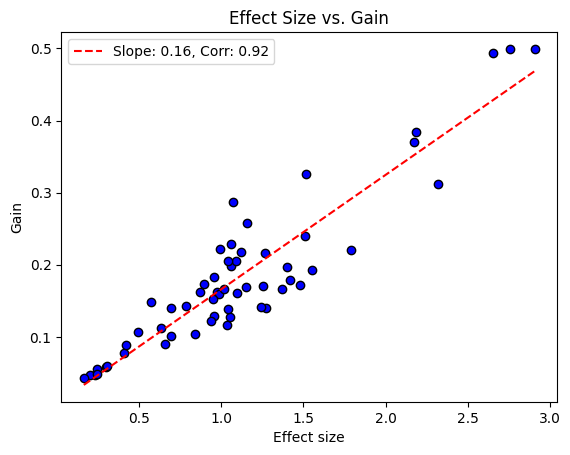

In [27]:
plt.scatter(effect_sizes, gains, color='blue', edgecolor='black'  )
plt.ylabel('Gain')
plt.xlabel('Effect size')

#fit line
m, b = np.polyfit(effect_sizes, gains, 1)
corr = np.corrcoef(effect_sizes, gains)[0, 1]
xi = np.linspace(min(effect_sizes), max(effect_sizes), 100)
plt.plot(xi, m*xi + b, 'r--', label=f'Slope: {m:.2f}, Corr: {corr:.2f}')
plt.legend()
plt.title('Effect Size vs. Gain')

## Pre Post Results

PreMean: mean=0.39, std=0.09, min=0.23, max=0.53
PostMean: mean=0.58, std=0.13, min=0.36, max=0.82
PreStd: mean=0.16, std=0.04, min=0.07, max=0.28
PostStd: mean=0.19, std=0.05, min=0.12, max=0.31


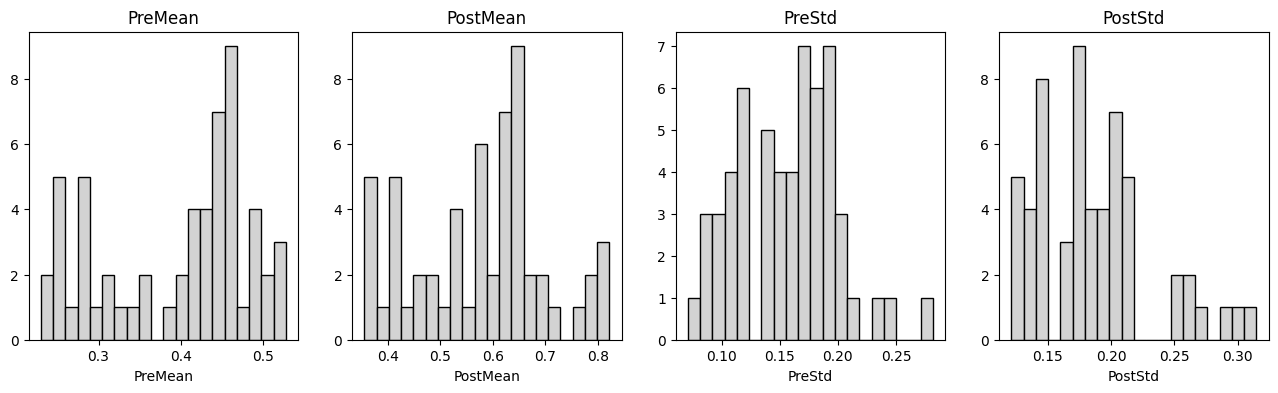

In [28]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
labels = ['PreMean', 'PostMean', 'PreStd', 'PostStd']
for i in range(len(labels)):
    ax[i].hist(data[labels[i]], bins=20, color='lightgray', edgecolor='black')
    print(f'{labels[i]}: mean={data[labels[i]].mean():.2f}, std={data[labels[i]].std():.2f}, min={data[labels[i]].min():.2f}, max={data[labels[i]].max():.2f}')
    ax[i].set_title(labels[i])
    ax[i].set_xlabel(labels[i])

## Lec = 1 - WG - CG
In our heatmaps we estimate the amount of lecture time as 1 - WG -CG. The below plot demonstrates that this is a reasonable estimate of an upper limit on the amount of lecture for various values of WG and CG in the datset.

Text(0.5, 1.0, 'Lec vs. 1- CG - WG')

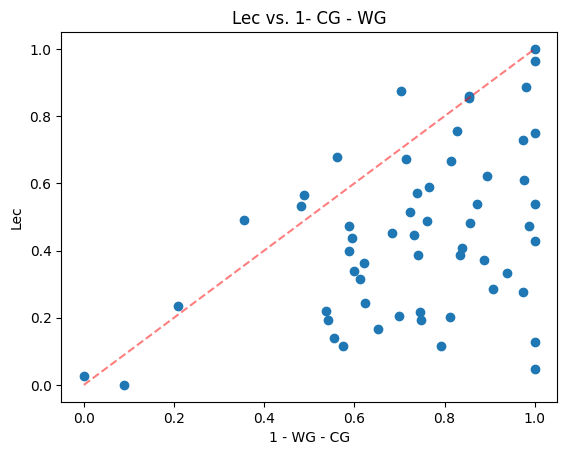

In [29]:
plt.scatter(1 - WGs -  CGs, Lecs)
plt.plot([0, 1], [0, 1], 'r--', alpha=0.5)
plt.xlabel('1 - WG - CG')
plt.ylabel('Lec')
plt.title( 'Lec vs. 1- CG - WG')


In [31]:
np.min(Ns), np.max(Ns), np.mean(Ns), np.std(Ns), np.sum(Ns)

(np.float64(11.0),
 np.float64(576.0),
 np.float64(163.2982456140351),
 np.float64(125.81676525000458),
 np.float64(9308.0))